In [1]:
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, auc, precision_recall_curve, r2_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MultiLabelBinarizer

from utils import fit_and_eval_cls, to_long_with_offsets, build_day_level_df

plt.rcParams.update({
    "axes.titlesize": 20,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

In [2]:
df = pd.read_csv("../data/patient_features_with_encounter_cluster.csv")

df['encounter_start_dt'] = pd.to_datetime(df['encounter_start_dt'], errors='coerce')
df['encounter_end_dt']   = pd.to_datetime(df['encounter_end_dt'],   errors='coerce')

df.proc_descs_seq_str

base_features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_medical_service', 'n_icd_prefix3',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
    # DO NOT include encounter_setting
]
base_features    = [c for c in base_features if c in df.columns]

In [3]:
all_columns = ['patient_id', 'encounter_id', 'icd_prefix3_unique_str', 'n_icd_prefix3',
       'encounter_start_dt', 'encounter_end_dt', 'encounter_duration_days',
       'encounter_setting', 'encounter_medical_service',
       'adt_event_types_seq_str', 'adt_event_times_seq_str',
       'PATIENT_BIRTH_YEAR', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
       'DECEASED_FLAG', 'age', 'med_order_nunique', 'proc_codes_seq_str',
       'proc_descs_seq_str', 'proc_times_seq_str', 'proc_count',
       'past_num_encounters', 'past_total_procedures', 'past_total_icd_codes',
       'past_total_encounter_days', 'encounter_cluster']

In [4]:
mlb = MultiLabelBinarizer(sparse_output=True)
df["proc_descs_seq_list"] = df.proc_descs_seq_str.fillna("").apply(
    lambda x: [str(code).strip() for code in x.split("|")] if x else []
)
proc_code_mlb = mlb.fit_transform(df["proc_descs_seq_list"])

codes_df = pd.DataFrame.sparse.from_spmatrix(
    proc_code_mlb,
    columns=mlb.classes_,
    index = df.index
)
mlb_columns = [i for i in list(mlb.classes_) if i not in df.columns.to_list()]
# additional_columns = list(tfidf.get_feature_names_out()) + list(mlb.classes_)
additional_columns = list(set(mlb_columns))
all_df = pd.concat([df, codes_df[mlb_columns]], axis=1)

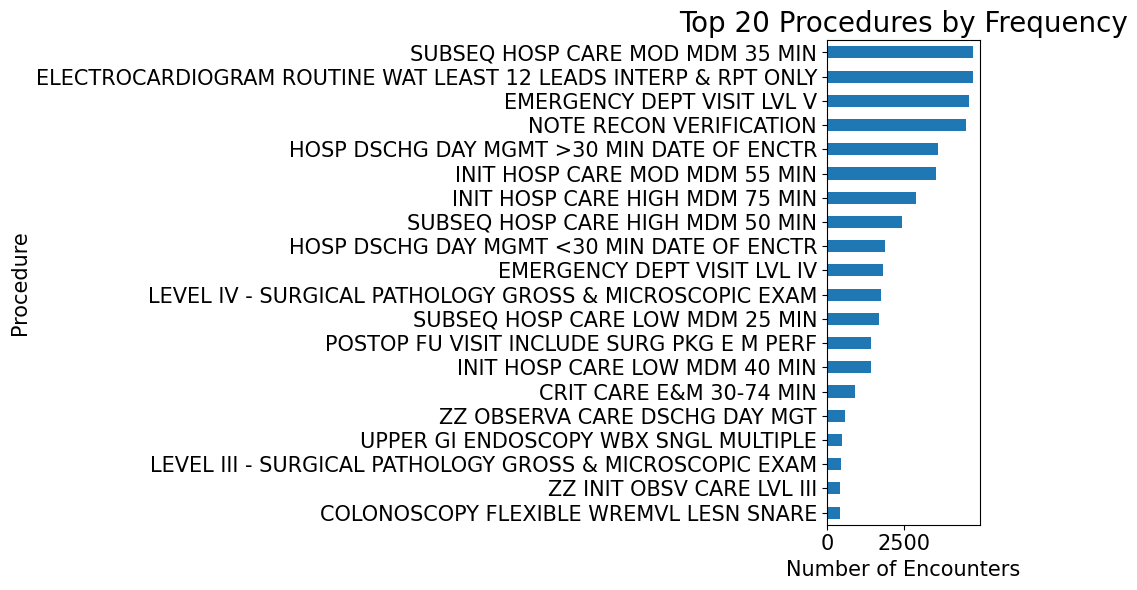

In [5]:
# series from earlier cell
procedure_counts = (df['proc_descs_seq_str'].fillna('')
      .astype(str)
      .str.split('|')
      .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts())

# bar plot of the most common procedures
procedure_counts.head(20).sort_values().plot(
    kind='barh', figsize=(10,6), color='C0'
)
plt.title('Top 20 Procedures by Frequency', size=20)
plt.xlabel('Number of Encounters', size=15)
plt.ylabel('Procedure', size=15)
plt.tight_layout()
plt.show()

In [6]:
groups = all_df['patient_id'].astype(str)
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(all_df, groups=groups))

df_train = all_df.iloc[train_idx].reset_index(drop=True)
df_test = all_df.iloc[test_idx].reset_index(drop=True)

In [7]:
results = []
results_df = pd.DataFrame()

top10_procedures = (df['proc_descs_seq_str'].fillna('').astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts()
      .head(10)).index.tolist()


In [8]:
roc_data = {} 
best_thresholds = {}

for procedure in top10_procedures:
    cls, prob_procedure, cls_metrics, best_thresh = fit_and_eval_cls(
        base_features, procedure, 
        f"Procedure {procedure}", df_train, df_test,
    )

    results_df[f"prob_{procedure}"] = prob_procedure
    best_thresholds[procedure] = best_thresh

    y_true = np.asarray(df_test[procedure].to_numpy()).astype(int)
    fpr, tpr, _ = roc_curve(y_true, prob_procedure)


    fpr, tpr, _ = roc_curve(y_true, prob_procedure)
    roc_auc = auc(fpr, tpr)
    roc_data[procedure] = (fpr, tpr, roc_auc)

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for SUBSEQ HOSP CARE MOD MDM 35 MIN: 0.700


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY: 0.700


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for SUBSEQ HOSP CARE HIGH MDM 50 MIN: 0.700


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR: 0.700
Best threshold for EMERGENCY DEPT VISIT LVL IV: 0.700


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


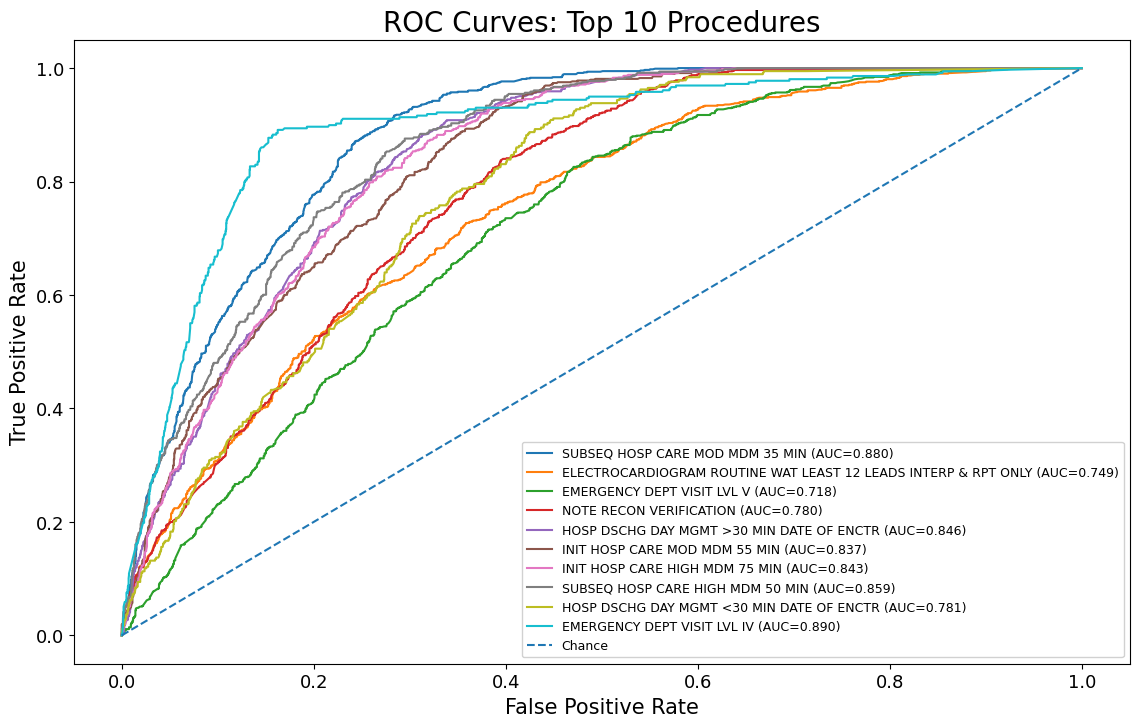

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

for procedure, (fpr, tpr, roc_auc) in roc_data.items():
    ax.plot(fpr, tpr, label=f"{procedure} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate", fontsize=15)
ax.set_ylabel("True Positive Rate", fontsize=15)
ax.set_title("ROC Curves: Top 10 Procedures", fontsize=20)

ax.tick_params(axis="both", labelsize=13)

ax.legend(
    loc="lower right",
    fontsize=9,
    frameon=True,
    framealpha=0.9
)

fig.subplots_adjust(left=0.08, right=0.96, top=0.90, bottom=0.12)

plt.savefig("figures/procedures/roc_curves_top10_procedures.png", bbox_inches="tight")

In [14]:
proc_desc = (df.proc_descs_seq_str.fillna('')
      .astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts())
proc_desc.head(10).index.tolist()

['SUBSEQ HOSP CARE MOD MDM 35 MIN',
 'ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY',
 'EMERGENCY DEPT VISIT LVL V',
 'NOTE RECON VERIFICATION',
 'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR',
 'INIT HOSP CARE MOD MDM 55 MIN',
 'INIT HOSP CARE HIGH MDM 75 MIN',
 'SUBSEQ HOSP CARE HIGH MDM 50 MIN',
 'HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR',
 'EMERGENCY DEPT VISIT LVL IV']

C:\Users\david\AppData\Local\Temp\ipykernel_31148\657131293.py:5: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if pd.api.types.is_sparse(y_true.dtype):


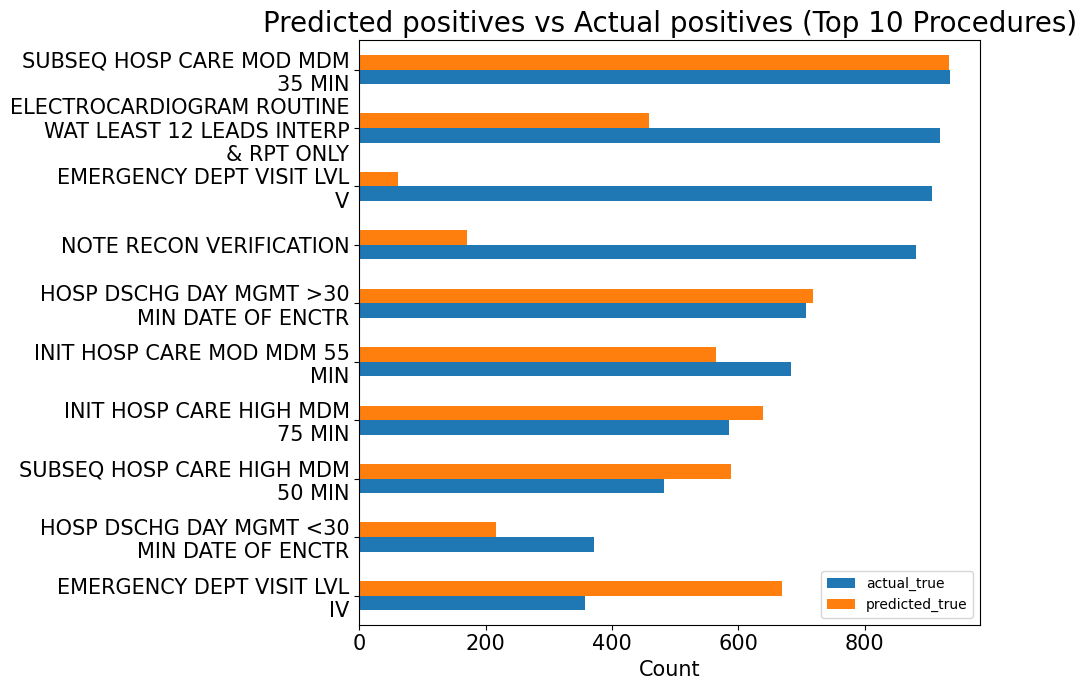

In [15]:
summary = []

for procedure in top10_procedures:
    y_true = df_test[procedure]
    if pd.api.types.is_sparse(y_true.dtype):
        y_true = y_true.sparse.to_dense()
    y_true = y_true.to_numpy().astype(int)

    y_prob = results_df[f"prob_{procedure}"].to_numpy()
    threshold = best_thresholds[procedure]
    y_pred = (y_prob >= threshold).astype(int)

    summary.append({
        "procedure": procedure,
        "actual_true": int(y_true.sum()),
        "predicted_true": int(y_pred.sum()),
    })

summary_df = pd.DataFrame(summary).set_index("procedure")
# summary_df.plot(kind="bar")

plot_df = summary_df.copy()
plot_df.index = [textwrap.fill(str(x), width=25) for x in plot_df.index]  # adjust width

ax = plot_df.sort_values("actual_true").plot(kind="barh", figsize=(10, 7))
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Predicted positives vs Actual positives (Top 10 Procedures)")
plt.tight_layout()
plt.savefig("figures/procedures/predicted_vs_actual_positives_top10_procedures.png")


# Predicting which day a procedure occurs

In [16]:
long_df = to_long_with_offsets(df)
dfs = []
procedures = ['SUBSEQ HOSP CARE MOD MDM 35 MIN',
 'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR',
 'INIT HOSP CARE MOD MDM 55 MIN',
 'INIT HOSP CARE HIGH MDM 75 MIN',
 'SUBSEQ HOSP CARE HIGH MDM 50 MIN',]
top10 = (df['proc_descs_seq_str'].fillna('').astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts()
      .head(10)).index.tolist()
for index, proc in enumerate(top10):
    if proc in procedures:
        dfs.append(build_day_level_df(df, long_df, proc, max_day=7, id_col="encounter_id"))

procedure_day_df = pd.concat(dfs, ignore_index=True)

features = base_features + [
    "day",          
    "procedure"       
]

procedure_day_df["day"] = pd.to_numeric(procedure_day_df["day"], errors="coerce")
groups = procedure_day_df['patient_id'].astype(str)
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(procedure_day_df, groups=groups))

procedure_day_df_train = procedure_day_df.iloc[train_idx].reset_index(drop=True)
procedure_day_df_test = procedure_day_df.iloc[test_idx].reset_index(drop=True)

pipe, proba, metrics, best_thresh = fit_and_eval_cls(
    feature_list=features,
    y_col="occurs",
    label="Day-level procedure model",
    df_train=procedure_day_df_train,
    df_test=procedure_day_df_test
)

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for occurs: 0.700


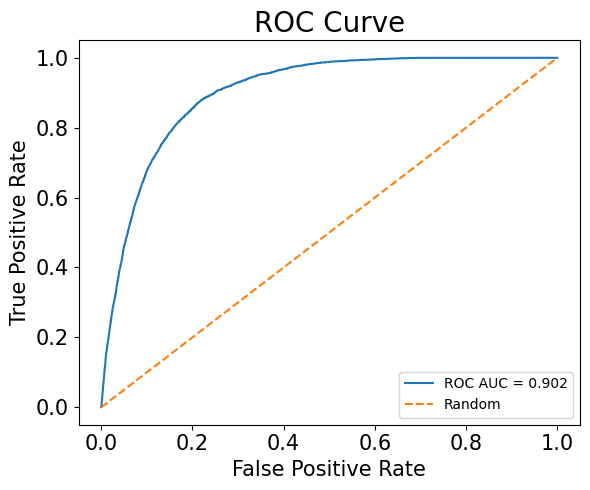

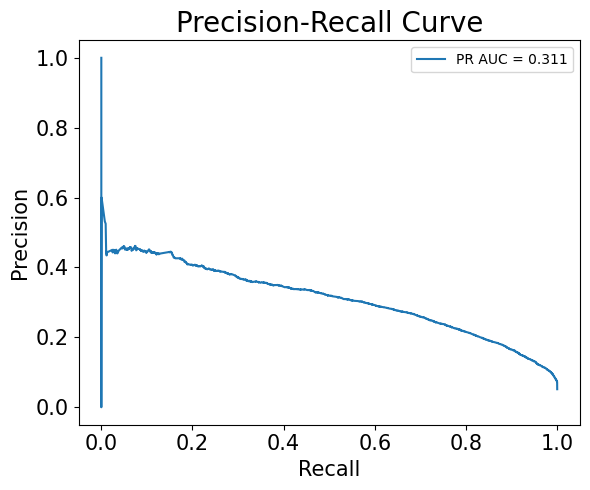

In [17]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

y_true = procedure_day_df_test["occurs"].to_numpy().astype(int)
y_score = proba

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate", size=15)
plt.ylabel("True Positive Rate", size=15)
plt.title("ROC Curve", size=20)
plt.legend()
plt.tight_layout()
plt.savefig("figures/procedures/day_level_procedure_model_roc_curve.png")
plt.show()

# Precision-recall
precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall", size=15)
plt.ylabel("Precision", size=15)
plt.title("Precision-Recall Curve", size=20)
plt.legend()
plt.tight_layout()
plt.savefig("figures/procedures/day_level_procedure_model_pr_curve.png")
plt.show()

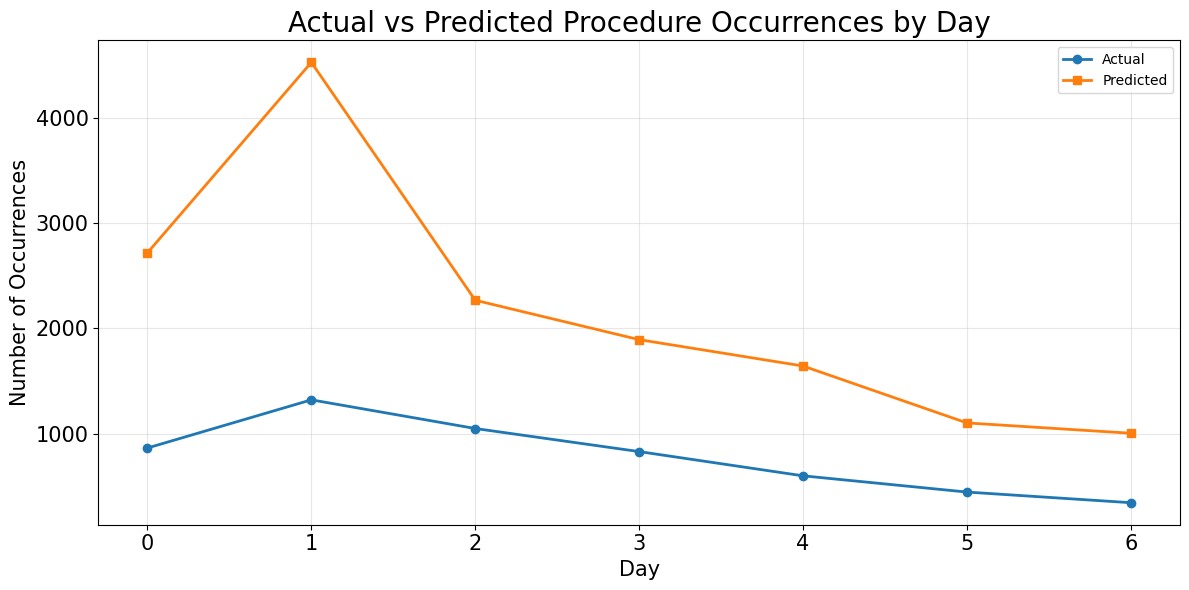

In [ ]:
day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= .85).astype(int)

daily_stats = day_summary.groupby('day').agg({
    'occurs': 'sum',
    'predicted': 'sum'
}).reset_index()
daily_stats.columns = ['day', 'actual', 'predicted']

plt.figure(figsize=(12, 6))
plt.plot(daily_stats['day'], daily_stats['actual'], marker='o', label='Actual', linewidth=2)
plt.plot(daily_stats['day'], daily_stats['predicted'], marker='s', label='Predicted', linewidth=2)
plt.xlabel('Day', size=15)
plt.ylabel('Number of Occurrences', size=15)
plt.title('Actual vs Predicted Procedure Occurrences by Day', size=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/procedures/daily_expected_vs_actual_procedure_occurrences.png")

In [52]:
proba

array([0.21766102, 0.8796752 , 0.8796752 , ..., 0.44422771, 0.38214215,
       0.33175598], shape=(105840,))

C:\Users\david\AppData\Local\Temp\ipykernel_24360\2771687453.py:5: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if pd.api.types.is_sparse(actual_df[c].dtype):


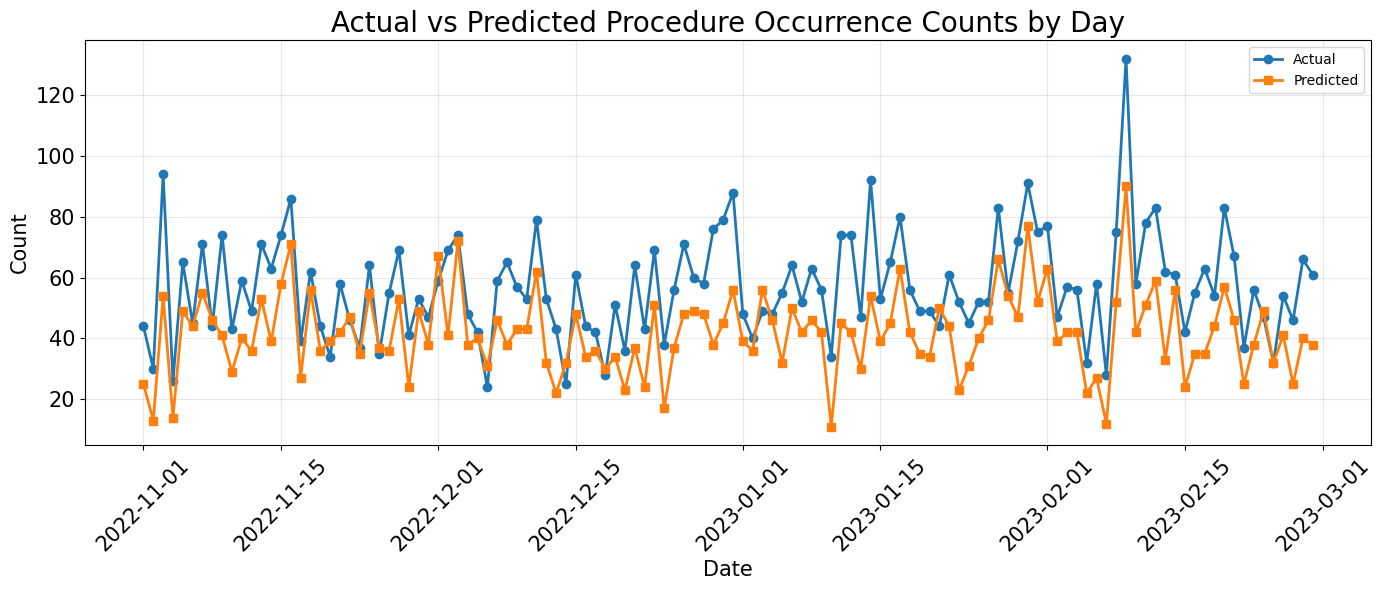

In [19]:
enc = df_test[['encounter_id','encounter_start_dt']].copy()
enc['encounter_start_dt'] = pd.to_datetime(enc['encounter_start_dt'], errors='coerce')
actual_df = df_test[top10_procedures].copy()
for c in actual_df.columns:
    if pd.api.types.is_sparse(actual_df[c].dtype):
        actual_df[c] = actual_df[c].sparse.to_dense()
actual_counts_per_enc = actual_df.fillna(0).astype(int).sum(axis=1)
predicted_df = pd.DataFrame({
    proc: (results_df[f"prob_{proc}"].to_numpy() >= best_thresholds[proc]).astype(int)
    for proc in top10_procedures
}, index=df_test.index)
predicted_counts_per_enc = predicted_df.sum(axis=1)
day_df = pd.DataFrame({
    'encounter_start_dt': enc['encounter_start_dt'],
    'actual_count': actual_counts_per_enc,
    'predicted_count': predicted_counts_per_enc
})
day_df['day'] = day_df['encounter_start_dt'].dt.floor('D')
daily_stats = day_df.groupby('day').agg({'actual_count':'sum','predicted_count':'sum'}).reset_index().sort_values('day')
plt.figure(figsize=(14,6))
plt.plot(daily_stats['day'], daily_stats['actual_count'], marker='o', label='Actual', linewidth=2)
plt.plot(daily_stats['day'], daily_stats['predicted_count'], marker='s', label='Predicted', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Actual vs Predicted Procedure Occurrence Counts by Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/procedures/daily_expected_vs_actual_procedure_occurrence_counts.png")

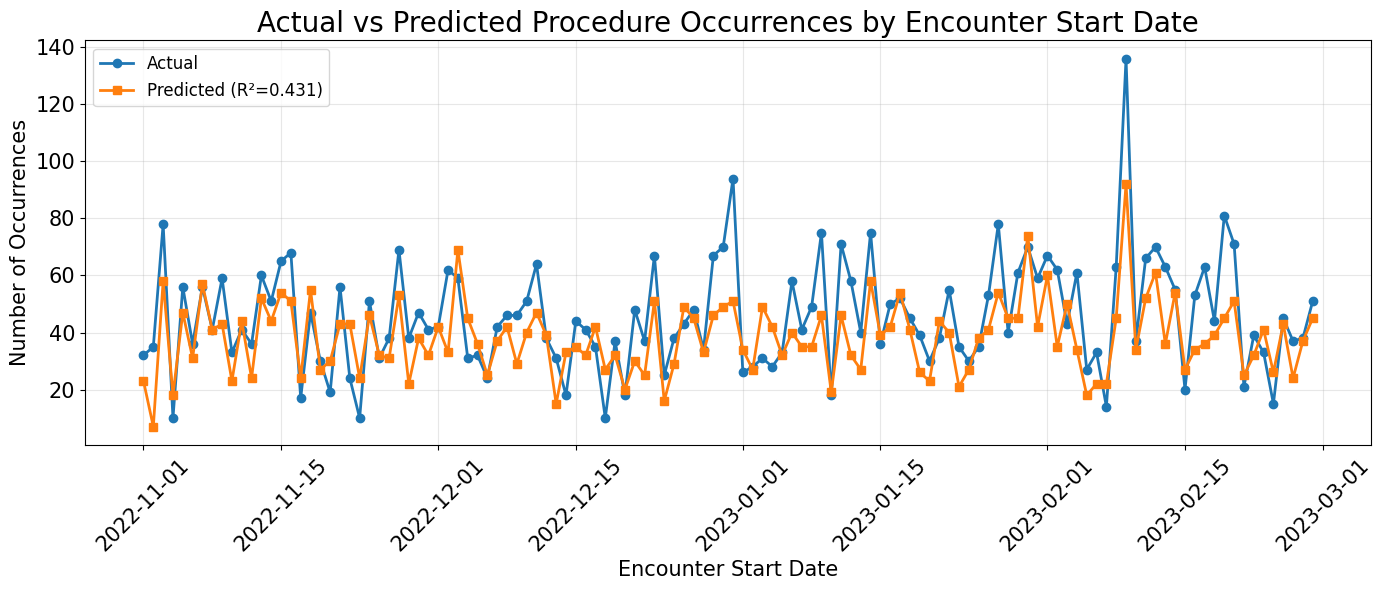

In [58]:
day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= .85).astype(int)

daily_stats = day_summary.groupby('encounter_start_dt').agg({
    'occurs': 'sum',
    'predicted': 'sum'
}).reset_index()

daily_stats.columns = ['encounter_start_dt', 'actual', 'predicted']
daily_stats = daily_stats.sort_values('encounter_start_dt')

r2 = r2_score(daily_stats['actual'], daily_stats['predicted'])

plt.figure(figsize=(14, 6))

plt.plot(
    daily_stats['encounter_start_dt'],
    daily_stats['actual'],
    marker='o',
    label='Actual',
    linewidth=2
)

plt.plot(
    daily_stats['encounter_start_dt'],
    daily_stats['predicted'],
    marker='s',
    label=f'Predicted (R²={r2:.3f})',
    linewidth=2
)

plt.xlabel('Encounter Start Date', fontsize=15)
plt.ylabel('Number of Occurrences', fontsize=15)
plt.title('Actual vs Predicted Procedure Occurrences by Encounter Start Date', fontsize=20)

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/procedures/daily_expected_vs_actual_procedure_occurrences_by_encounter_start_date.png")

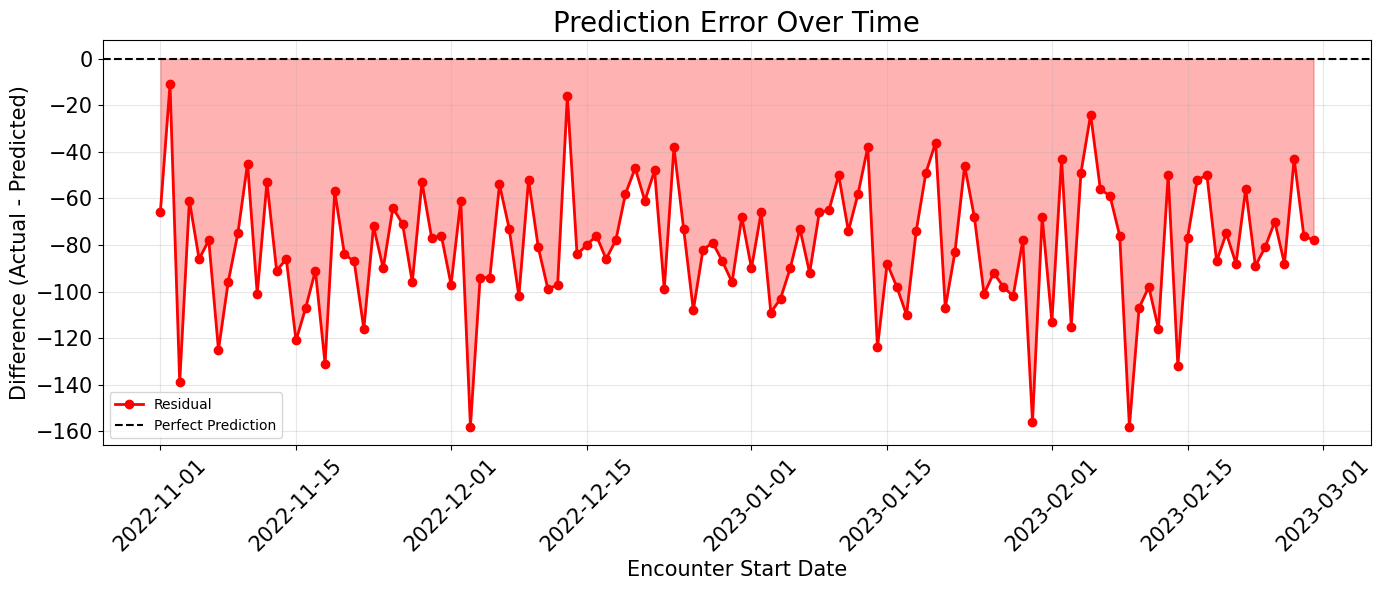

Mean Error: -80.75
Std Dev: 27.26
Min Error: -158.00
Max Error: -11.00


In [21]:

day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= best_thresh).astype(int)
day_summary['encounter_start_dt'] = pd.to_datetime(day_summary['encounter_start_dt'], errors='coerce')

daily_stats = (
    day_summary.groupby('encounter_start_dt')
    .agg({'occurs': 'sum', 'predicted': 'sum'})
    .reset_index()
    .rename(columns={'occurs': 'actual'})
    .sort_values('encounter_start_dt')
)

# Calculate residuals (error)
daily_stats['residual'] = daily_stats['actual'] - daily_stats['predicted']

# Plot residuals over time
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['encounter_start_dt'], daily_stats['residual'], marker='o', linewidth=2, color='red', label='Residual')
plt.axhline(y=0, color='black', linestyle='--', label='Perfect Prediction')
plt.fill_between(daily_stats['encounter_start_dt'], 0, daily_stats['residual'], alpha=0.3, color='red')
plt.xlabel('Encounter Start Date')
plt.ylabel('Difference (Actual - Predicted)')
plt.title('Prediction Error Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Mean Error: {daily_stats['residual'].mean():.2f}")
print(f"Std Dev: {daily_stats['residual'].std():.2f}")
print(f"Min Error: {daily_stats['residual'].min():.2f}")
print(f"Max Error: {daily_stats['residual'].max():.2f}")

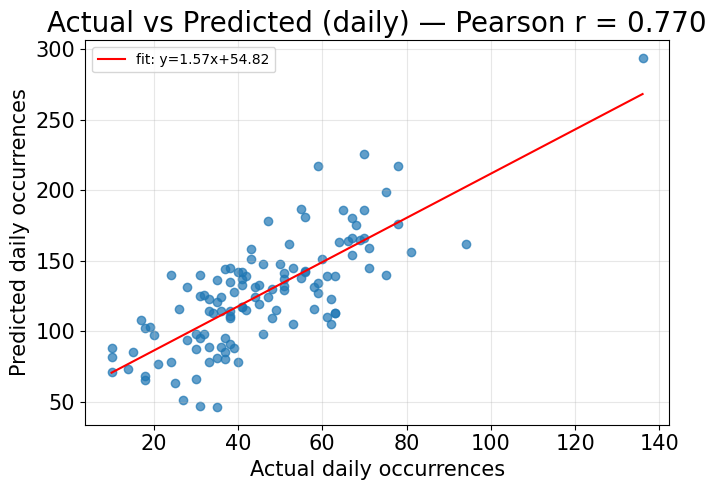

In [22]:
day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= best_thresh).astype(int)
day_summary['encounter_start_dt'] = pd.to_datetime(day_summary['encounter_start_dt'], errors='coerce')

daily_stats = (
    day_summary.groupby('encounter_start_dt')
    .agg({'occurs': 'sum', 'predicted': 'sum'})
    .reset_index()
    .rename(columns={'occurs': 'actual', 'predicted': 'predicted'})
    .sort_values('encounter_start_dt')
)

r = np.nan
if len(daily_stats) >= 2:
    r = np.corrcoef(daily_stats['actual'], daily_stats['predicted'])[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(daily_stats['actual'], daily_stats['predicted'], alpha=0.7)
if daily_stats['actual'].nunique() > 1:
    m, b = np.polyfit(daily_stats['actual'], daily_stats['predicted'], 1)
    xs = np.linspace(daily_stats['actual'].min(), daily_stats['actual'].max(), 100)
    plt.plot(xs, m * xs + b, color='red', label=f'fit: y={m:.2f}x+{b:.2f}')
plt.xlabel('Actual daily occurrences')
plt.ylabel('Predicted daily occurrences')
plt.title(f'Actual vs Predicted (daily) — Pearson r = {r:.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# map patient id to list of procedures

In [23]:
patient_proc_map = {}
for pid, seq in zip(df['patient_id'], df['proc_descs_seq_str']):
    if pd.isna(seq):
        patient_proc_map[pid] = set()
    else:
        descs = [s.strip() for s in str(seq).split('|') if s.strip()]
        patient_proc_map[pid] = descs

In [24]:
patient_proc_map

{'0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43ec9bdd780ba110cbcad': ['ZZ INIT OBSV CARE LVL III',
  'ZZ SUBSEQ OBSV CARE LVL 2',
  'ZZ OBSERVA CARE DSCHG DAY MGT'],
 '00010b29ec5fd2ad40834318f6b429961059a614fbfece07587989bb28c43451': ['ZZ INIT OBSV CARE LVL II',
  'EMERGENCY DEPT VISIT LVL V',
  'ANESTH UPPER GASTROINTSTNL ENDO PROC, SCOPE  PROXIMAL TO DUODENUM; NOS',
  'NOTE RECON VERIFICATION',
  'UPPER GI ENDOSCOPY WREMVL FB',
  'ZZ SUBSEQ OBSV CARE LVL 3',
  'OFFICE OP VISIT NEW PT LEVEL III',
  'NOTE RECON VERIFICATION',
  'ZZ OBSERVA CARE DSCHG DAY MGT',
  'OFFICE OP VISIT EST PT LEVEL II'],
 '00069f08d03e7656de01529806a59e6f7802f7d2380b3b3d05755afcbe85081c': ['INIT HOSP CARE MOD MDM 55 MIN',
  'SUBSEQ HOSP CARE MOD MDM 35 MIN',
  'SUBSEQ HOSP CARE LOW MDM 25 MIN',
  'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR'],
 '0011226504d8e566cd00f2fd24dab680409b58aa39fa9b523f46d541c7f2c673': ['ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY',
  'EMERGENCY DEPT VISIT LVL V',
 

In [25]:
import pandas as pd

column_definitions = {
    "patient_id": "Unique identifier for the patient.",
    "encounter_id": "Unique identifier for the healthcare encounter/visit.",
    "icd_prefix3_unique_str": "String representation of the unique 3-character ICD code prefixes associated with the encounter.",
    "n_icd_prefix3": "Number of unique 3-character ICD code prefixes recorded for the encounter.",
    "encounter_start_dt": "Datetime when the encounter began.",
    "encounter_end_dt": "Datetime when the encounter ended.",
    "encounter_duration_days": "Duration of the encounter in days.",
    "encounter_setting": "Care setting for the encounter, such as inpatient, outpatient, emergency, or observation.",
    "encounter_medical_service": "Clinical service line or specialty associated with the encounter.",
    "adt_event_types_seq_str": "Ordered string of ADT event types during the encounter (for example admission, transfer, discharge).",
    "adt_event_times_seq_str": "Ordered string of timestamps corresponding to the ADT events during the encounter.",
    "PATIENT_BIRTH_YEAR": "Patient year of birth.",
    "PATIENT_SEX": "Recorded sex of the patient.",
    "PATIENT_RACE_ETHNICITY": "Recorded race and/or ethnicity category for the patient.",
    "DECEASED_FLAG": "Indicator for whether the patient is recorded as deceased.",
    "age": "Patient age at the time of the encounter.",
    "med_order_nunique": "Number of unique medication orders placed during the encounter.",
    "proc_codes_seq_str": "Ordered string of procedure codes recorded during the encounter.",
    "proc_descs_seq_str": "Ordered string of procedure descriptions corresponding to the procedure codes.",
    "proc_times_seq_str": "Ordered string of timestamps for procedures during the encounter.",
    "proc_count": "Total number of procedures recorded during the encounter.",
    "past_num_encounters": "Number of prior encounters for the patient before this encounter.",
    "past_total_procedures": "Total number of procedures across all prior encounters.",
    "past_total_icd_codes": "Total number of ICD codes across all prior encounters.",
    "past_total_encounter_days": "Total days spent across all prior encounters.",
    "encounter_cluster": "Cluster or grouped category assigned to the encounter, likely derived from utilization, diagnosis, or procedure patterns."
}

df_defs = pd.DataFrame(
    [{"column_name": col, "definition": desc} for col, desc in column_definitions.items()]
)

df_defs.to_csv("column_definitions.csv", index=False)
print("Saved to column_definitions.csv")

Saved to column_definitions.csv


In [32]:
# Define estimated times for procedures
times = {
    "SUBSEQ HOSP CARE MOD MDM 35 MIN": 35,
    "ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY": 7,
    "EMERGENCY DEPT VISIT LVL V": 75,
    "NOTE RECON VERIFICATION": 10,
    "HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR": 40,
    "INIT HOSP CARE MOD MDM 55 MIN": 55,
    "INIT HOSP CARE HIGH MDM 75 MIN": 75,
    "SUBSEQ HOSP CARE HIGH MDM 50 MIN": 50,
    "HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR": 20,
    "EMERGENCY DEPT VISIT LVL IV": 45
}

In [ ]:
# Compute actual and predicted times per encounter
actual_times = []
predicted_times = []

for idx in df_test.index:
    # Actual times
    actual_procs = []
    for proc in top10_procedures:
        y_true = df_test[proc]
        if pd.api.types.is_sparse(y_true.dtype):
            y_true = y_true.sparse.to_dense()
        val = y_true.iloc[idx]
        if val == 1:
            actual_procs.append(proc)
    time_sum_actual = sum(times.get(proc, 0) for proc in actual_procs)
    actual_times.append(time_sum_actual)
    
    # Predicted times (proba > 0.65)
    pred_procs = [proc for proc in top10_procedures if results_df.loc[idx, f"prob_{proc}"] > 0.]
    time_sum_pred = sum(times.get(proc, 0) for proc in pred_procs)
    predicted_times.append(time_sum_pred)

enc = df_test[['encounter_id','encounter_start_dt']].copy()
enc['encounter_start_dt'] = pd.to_datetime(enc['encounter_start_dt'], errors='coerce')

day_df_times = pd.DataFrame({
    'encounter_start_dt': enc['encounter_start_dt'],
    'actual_time': actual_times,
    'predicted_time': predicted_times
})

day_df_times['day'] = day_df_times['encounter_start_dt'].dt.floor('D')
daily_stats_times = day_df_times.groupby('day').agg({'actual_time':'sum','predicted_time':'sum'}).reset_index().sort_values('day')

C:\Users\david\AppData\Local\Temp\ipykernel_24360\205108902.py:10: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if pd.api.types.is_sparse(y_true.dtype):


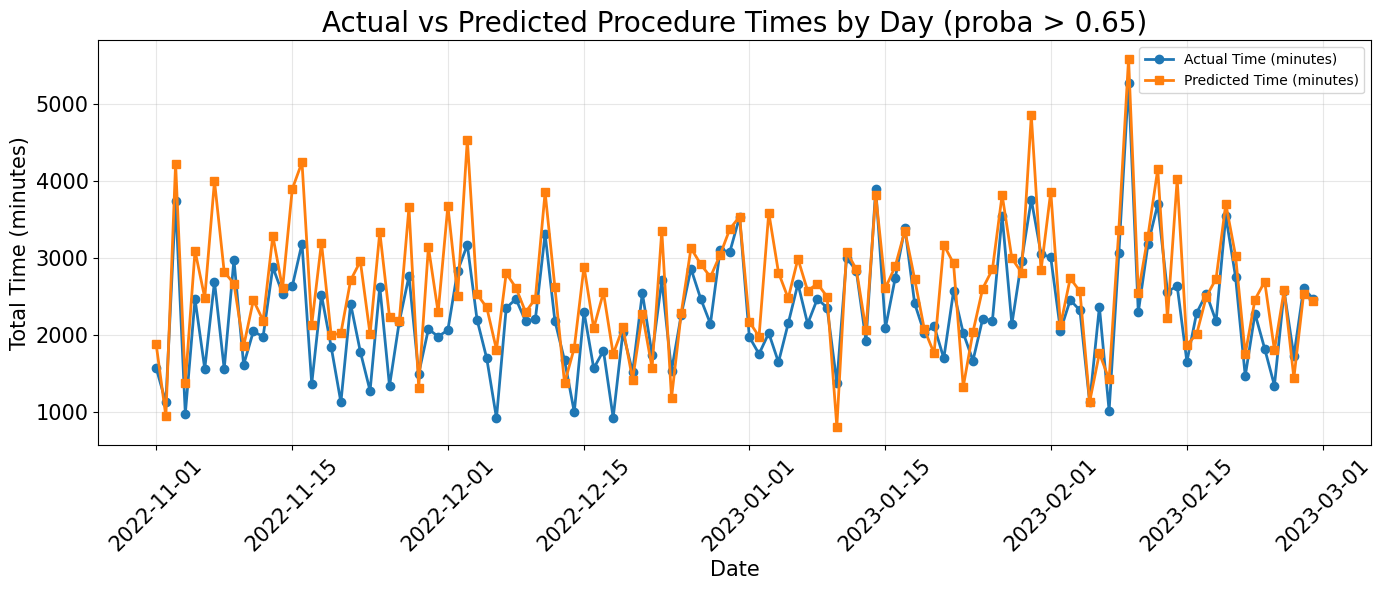

In [48]:
plt.figure(figsize=(14,6))
plt.plot(daily_stats_times['day'], daily_stats_times['actual_time'], marker='o', label='Actual Time (minutes)', linewidth=2)
plt.plot(daily_stats_times['day'], daily_stats_times['predicted_time'], marker='s', label='Predicted Time (minutes)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Total Time (minutes)')
plt.title('Actual vs Predicted Procedure Times by Day (proba > 0.65)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/procedures/daily_expected_vs_actual_procedure_times.png")